# Decode Lab - Project 3
##Customer Segmentation using Unsupervised Learning

**STEP 1 - Importing Required Libraries**

In [221]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

**STEP 2 - Loading the Dataset**

In [222]:
df = pd.read_csv("marketing_campaign.csv", sep="\t")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


**STEP 3 - Understanding the Dataset**

3.1 Dataset Shape

In [223]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 2240
Number of Columns : 29


3.2 Column Names

In [224]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

3.3 Dataset Information

In [225]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

3.4 Statistical Summary

In [226]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


3.5 Random Sample

In [227]:
df.sample(5, random_state=42)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
324,2607,1953,Graduation,Single,40464.0,0,1,11-01-2013,78,424,...,8,0,0,0,0,0,0,3,11,0
96,7247,1960,Graduation,Widow,47916.0,0,1,22-11-2012,72,505,...,6,0,1,0,0,0,0,3,11,0
2104,5802,1972,Basic,Married,14188.0,0,0,28-02-2013,40,2,...,6,0,0,0,0,0,0,3,11,0
1259,2147,1969,Graduation,Together,76653.0,0,0,16-08-2013,91,736,...,2,0,0,1,1,0,0,3,11,0
1061,3759,1958,Graduation,Together,65196.0,0,2,25-07-2013,34,743,...,5,1,0,0,0,0,0,3,11,0


**STEP 4 - Data Quality Checks**

4.1 Check Missing Values

In [228]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


4.2 Check Duplicate Rows

In [229]:
df.duplicated().sum()

np.int64(0)

4.3 Check Duplicate Customer IDs

In [230]:
df["ID"].duplicated().sum()

np.int64(0)

4.4 Check Unique Values in Categorical Columns

In [231]:
print("Education:")
print(df["Education"].value_counts())

print("\nMarital Status:")
print(df["Marital_Status"].value_counts())

Education:
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

Marital Status:
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


In [232]:
df["Dt_Customer"].head()

,Dt_Customer
0,04-09-2012
1,08-03-2014
2,21-08-2013
3,10-02-2014
4,19-01-2014


4.5 Check for Suspicious Values

In [233]:
print("Income range:", df["Income"].min(), "to", df["Income"].max())
print("Year of Birth range:", df["Year_Birth"].min(), "to", df["Year_Birth"].max())
print("Recency range:", df["Recency"].min(), "to", df["Recency"].max())

Income range: 1730.0 to 666666.0
Year of Birth range: 1893 to 1996
Recency range: 0 to 99


**STEP 5 - Data Cleaning**

5.1 Handle Missing Income

In [234]:
df = df.dropna(subset=["Income"])

print("Rows after removing missing Income:", df.shape[0])

Rows after removing missing Income: 2216


5.2 Remove the Suspicious Year of Birth

In [235]:
df[df["Year_Birth"] < 1900]
df = df[df["Year_Birth"] >= 1900]

print("Rows after removing invalid birth years:", df.shape[0])

Rows after removing invalid birth years: 2214


5.3 Check the Suspicious Marital Status Values

In [236]:
df[df["Marital_Status"].isin(["Absurd", "Alone", "YOLO"])]
print("Rows after removing invalid marital status values:", df.shape[0])

Rows after removing invalid marital status values: 2214


5.4 Verify Cleaning

In [237]:
print("Missing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nInvalid birth years:")
print((df["Year_Birth"] < 1900).sum())

print("\nRemaining marital statuses:")
print(df["Marital_Status"].value_counts())

Missing values:
0

Duplicate rows:
0

Invalid birth years:
0

Remaining marital statuses:
Marital_Status
Married     857
Together    572
Single      470
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


**STEP 6 - Feature Engineering**

6.1 Total Spending

In [238]:
df["TotalSpent"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

6.2 Total Purchases

In [239]:
df["TotalPurchases"] = (
    df["NumDealsPurchases"] +
    df["NumWebPurchases"] +
    df["NumCatalogPurchases"] +
    df["NumStorePurchases"]
)

6.3 Total Children

In [240]:
df["TotalChildren"] = df["Kidhome"] + df["Teenhome"]

6.4 Customer Age

In [241]:
df["Age"] = 2024 - df["Year_Birth"]

6.5 Check the New Features

In [242]:
df[["Age", "TotalSpent", "TotalPurchases", "TotalChildren"]].head()

,Age,TotalSpent,TotalPurchases,TotalChildren
0,67,1617,25,0
1,70,27,6,2
2,59,776,21,0
3,40,53,8,1
4,43,422,19,1


**STEP 7 - Selecting Features for Clustering**

7.1 Select Clustering Features

In [243]:
clustering_features = [
    "Income",
    "Age",
    "TotalChildren",
    "TotalSpent",
    "TotalPurchases",
    "NumWebVisitsMonth",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "Recency"
]

X = df[clustering_features]

print("Number of Features:", X.shape[1])
print("Feature Matrix Shape:", X.shape)

Number of Features: 11
Feature Matrix Shape: (2214, 11)


7.2 Check the Selected Features

In [244]:
X.head()
X.describe()

,Income,Age,TotalChildren,TotalSpent,TotalPurchases,NumWebVisitsMonth,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Recency
count,2214.000000,2214.000000,2214.000000,2214.000000,2214.000000,2214.000000,2214.000000,2214.000000,2214.000000,2214.000000,2214.000000
mean,52229.537037,55.113821,0.947606,606.776874,14.885727,5.321590,2.324752,4.086721,2.670732,5.803523,49.030262
std,25175.095832,11.788912,0.749129,602.462660,7.670935,2.424553,1.924173,2.741404,2.926650,3.251023,28.954824
min,1730.000000,28.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35265.000000,47.000000,0.000000,69.000000,8.000000,3.000000,1.000000,2.000000,0.000000,3.000000,24.000000
50%,51371.000000,54.000000,1.000000,396.500000,15.000000,6.000000,2.000000,4.000000,2.000000,5.000000,49.000000
75%,68487.000000,65.000000,1.000000,1047.750000,21.000000,7.000000,3.000000,6.000000,4.000000,8.000000,74.000000
max,666666.000000,124.000000,3.000000,2525.000000,44.000000,20.000000,15.000000,27.000000,28.000000,13.000000,99.000000


**STEP 8 - Feature Scaling**

In [245]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Feature Shape:", X_scaled.shape)

Scaled Feature Shape: (2214, 11)


**STEP 9 — PCA (Principal Component Analysis)**

9.1 Apply PCA

In [246]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("Original Feature Shape:", X_scaled.shape)
print("PCA Feature Shape:", X_pca.shape)

Original Feature Shape: (2214, 11)
PCA Feature Shape: (2214, 11)


9.2 Check Explained Variance

In [247]:
explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
print(explained_variance)

Explained Variance Ratio:
[4.23202039e-01 1.68308939e-01 9.41090582e-02 8.93705373e-02
 6.29040772e-02 4.71930889e-02 4.26824639e-02 2.91382713e-02
 2.75917551e-02 1.54997699e-02 6.80965507e-17]


9.3 Plot Cumulative Explained Variance

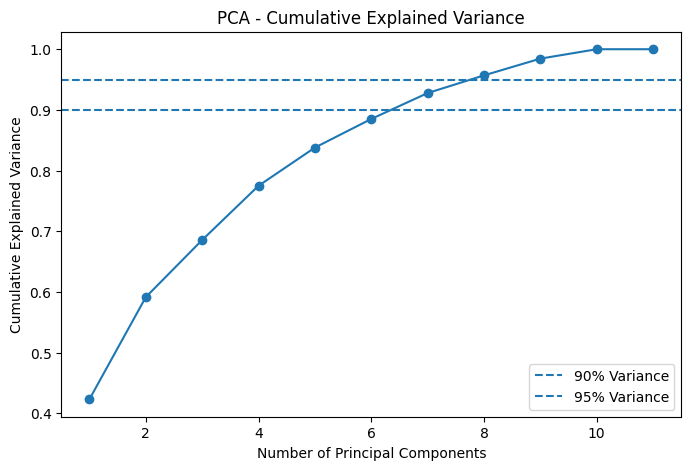

In [248]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(y=0.90, linestyle="--", label="90% Variance")
plt.axhline(y=0.95, linestyle="--", label="95% Variance")

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")

plt.legend()
plt.show()

STEP 9.4 — Select PCA Components

In [249]:
pca_final = PCA(n_components=8)

X_pca_final = pca_final.fit_transform(X_scaled)

print("Original Feature Shape:", X_scaled.shape)
print("Reduced Feature Shape:", X_pca_final.shape)
print("Total Explained Variance:", pca_final.explained_variance_ratio_.sum())

Original Feature Shape: (2214, 11)
Reduced Feature Shape: (2214, 8)
Total Explained Variance: 0.9569084750493573


**STEP 10 — Choosing the Optimal Number of Clusters**

10.1 Elbow Method

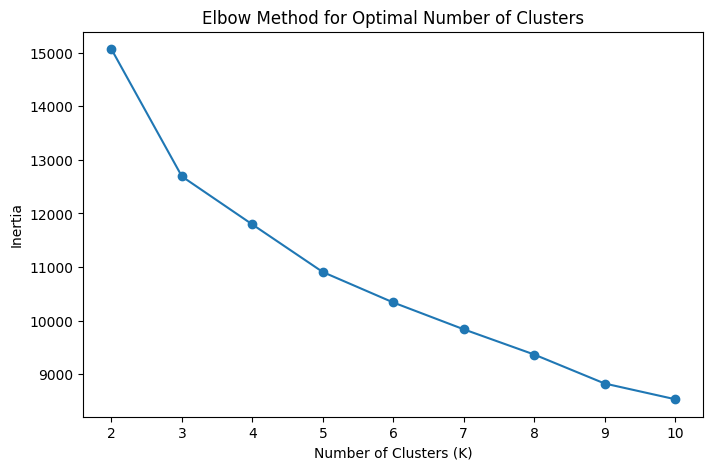

In [250]:
inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_pca_final)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Number of Clusters")

plt.show()

10.2 Silhouette Score Analysis

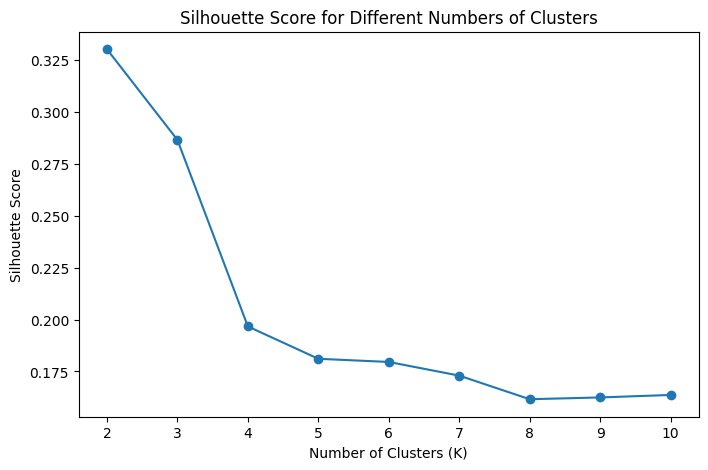

In [251]:
silhouette_scores = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_pca_final)

    score = silhouette_score(X_pca_final, cluster_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))

plt.plot(K, silhouette_scores, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different Numbers of Clusters")

plt.show()

**STEP 11 — Final K-Means Clustering**

11.1 Train the final K-Means model

In [252]:
final_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

df["Cluster"] = final_kmeans.fit_predict(X_pca_final)

print("Cluster Distribution:")
print(df["Cluster"].value_counts())

Cluster Distribution:
Cluster
1    1175
0    1039
Name: count, dtype: int64


11.2 Check the cluster percentages

In [253]:
cluster_percentage = df["Cluster"].value_counts(normalize=True) * 100

print("Cluster Percentage:")
print(cluster_percentage)

Cluster Percentage:
Cluster
1    53.071364
0    46.928636
Name: proportion, dtype: float64


11.3 Visualize the clusters

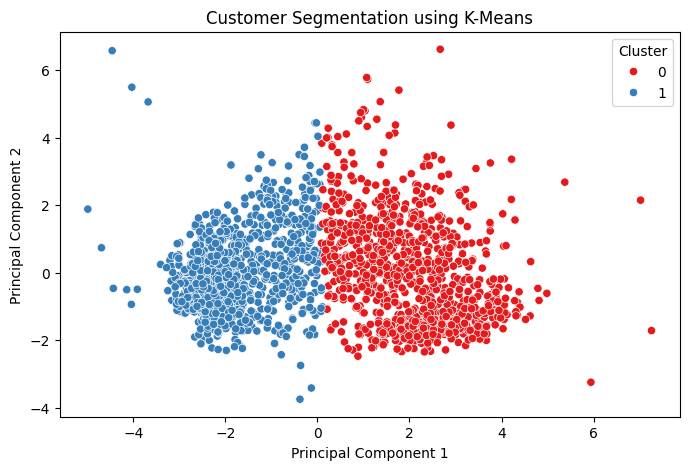

In [254]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=X_pca_final[:, 0],
    y=X_pca_final[:, 1],
    hue=df["Cluster"],
    palette="Set1"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation using K-Means")

plt.legend(title="Cluster")
plt.show()

11.4 Analyze the clusters

In [255]:
cluster_profile = df.groupby("Cluster")[
    [
        "Income",
        "Age",
        "TotalChildren",
        "TotalSpent",
        "TotalPurchases",
        "NumWebVisitsMonth",
        "NumDealsPurchases",
        "NumWebPurchases",
        "NumCatalogPurchases",
        "NumStorePurchases",
        "Recency"
    ]
].mean()

cluster_profile

,Income,Age,TotalChildren,TotalSpent,TotalPurchases,NumWebVisitsMonth,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Recency
Cluster,,,,,,,,,,,
0,69918.845043,57.184793,0.599615,1139.929740,21.509143,4.008662,2.328200,5.853705,4.903754,8.423484,49.232916
1,36587.672340,53.282553,1.255319,135.333617,9.028936,6.482553,2.321702,2.524255,0.696170,3.486809,48.851064


**STEP 12 — Cluster-wise Comparison**

12.1 Compare Total Spending

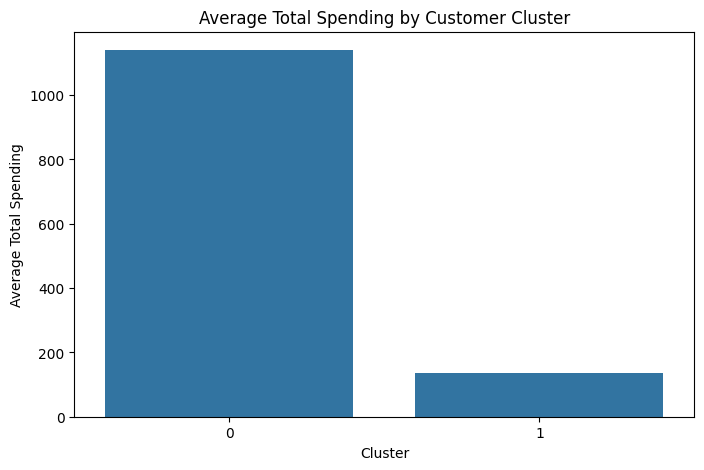

In [256]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=cluster_profile.index,
    y=cluster_profile["TotalSpent"]
)

plt.xlabel("Cluster")
plt.ylabel("Average Total Spending")
plt.title("Average Total Spending by Customer Cluster")

plt.show()

12.2 Compare Income

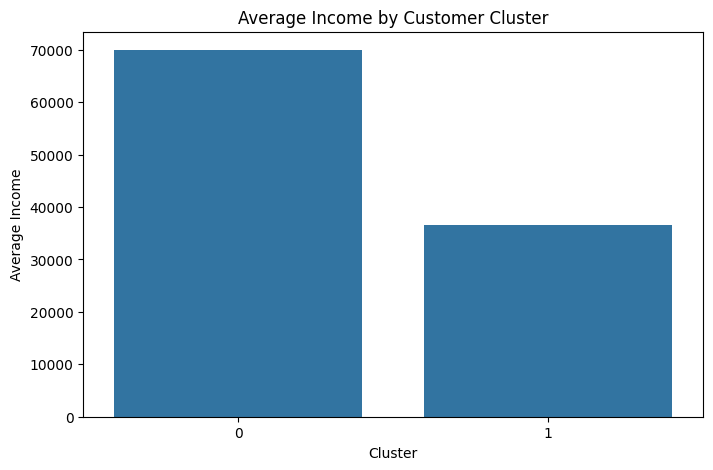

In [257]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=cluster_profile.index,
    y=cluster_profile["Income"]
)

plt.xlabel("Cluster")
plt.ylabel("Average Income")
plt.title("Average Income by Customer Cluster")

plt.show()

12.3 Compare Total Purchases

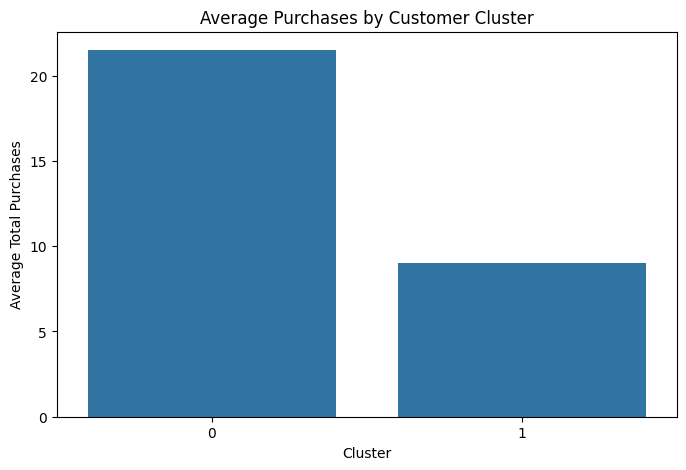

In [258]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=cluster_profile.index,
    y=cluster_profile["TotalPurchases"]
)

plt.xlabel("Cluster")
plt.ylabel("Average Total Purchases")
plt.title("Average Purchases by Customer Cluster")

plt.show()

12.4 Create a Customer Segment Label

In [259]:
df["Segment"] = df["Cluster"].map({
    0: "High-Value Customers",
    1: "Low-Value Customers"
})

print(df["Segment"].value_counts())

df[["ID", "Income", "TotalSpent", "TotalPurchases", "Cluster", "Segment"]].head()

Segment
Low-Value Customers     1175
High-Value Customers    1039
Name: count, dtype: int64


,ID,Income,TotalSpent,TotalPurchases,Cluster,Segment
0,5524,58138.0,1617,25,0,High-Value Customers
1,2174,46344.0,27,6,1,Low-Value Customers
2,4141,71613.0,776,21,0,High-Value Customers
3,6182,26646.0,53,8,1,Low-Value Customers
4,5324,58293.0,422,19,0,High-Value Customers


**STEP 13 — Final Cluster Profile**

In [260]:
final_profile = df.groupby("Segment")[
    [
        "Income",
        "Age",
        "TotalChildren",
        "TotalSpent",
        "TotalPurchases",
        "NumWebVisitsMonth",
        "NumDealsPurchases",
        "NumWebPurchases",
        "NumCatalogPurchases",
        "NumStorePurchases",
        "Recency"
    ]
].mean().round(2)

final_profile

,Income,Age,TotalChildren,TotalSpent,TotalPurchases,NumWebVisitsMonth,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Recency
Segment,,,,,,,,,,,
High-Value Customers,69918.85,57.18,0.60,1139.93,21.51,4.01,2.33,5.85,4.9,8.42,49.23
Low-Value Customers,36587.67,53.28,1.26,135.33,9.03,6.48,2.32,2.52,0.7,3.49,48.85


**STEP 14 — Final Insights**

### Customer Segmentation Insights

- The K-Means model divided customers into two distinct segments.
- High-Value Customers account for approximately 46.93% of the customer base.
- Low-Value Customers account for approximately 53.07% of the customer base.
- High-Value Customers have substantially higher average income than Low-Value Customers.
- High-Value Customers show significantly higher total spending and purchase frequency.
- High-Value Customers also have higher activity across web, catalog, and store purchasing channels.
- Low-Value Customers have lower spending and purchase activity despite representing the larger customer segment.
- The segmentation indicates that income and purchasing behavior are important factors for distinguishing customer groups.

### Business Recommendations

- High-Value Customers can be targeted with loyalty programs and personalized offers to encourage retention.
- Exclusive promotions and premium product recommendations can be used for high-value customers.
- Low-Value Customers can be targeted with introductory offers and personalized campaigns to increase engagement and spending.
- Web, catalog, and store purchasing behavior can be used to design channel-specific marketing strategies.
- Customer segmentation can help businesses allocate marketing resources more effectively.

## **STEP 15 - Conclusion**

K-Means clustering was used to segment customers based on demographic, purchasing, spending, and engagement-related features.

The analysis identified two major customer segments: High-Value Customers and Low-Value Customers. High-Value Customers demonstrated substantially higher income, spending, and purchase activity across multiple channels, while Low-Value Customers showed comparatively lower spending and purchasing behavior.

The resulting segmentation provides a useful basis for targeted marketing strategies, customer retention, and personalized offers.